 **STD_ID: 24118593**

**Github link: https://github.com/hibabtl/IMPACT-OF-NEURAL-NETWORK-DEPTH-ON-LEARNING-NON-LINEAR-DECISION-BOUNDARIES**

In [ ]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Generate dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X)

[[-0.11166654  0.52022374]
 [ 1.14264982 -0.34257734]
 [ 0.79555796 -0.01144231]
 ...
 [ 1.72760808 -0.42882943]
 [-1.01448644  0.13522904]
 [ 0.77438101  0.63428493]]


In [ ]:
def create_model(hidden_layers):
    model = Sequential()

    # Input layer
    model.add(Dense(hidden_layers[0], activation='relu', input_shape=(2,)))

    # Hidden layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation='relu'))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
# Model A: Shallow
model_1 = create_model([8])

# Model B: Medium depth
model_3 = create_model([16, 16, 8])

# Model C: Deep
model_5 = create_model([32, 32, 16, 16, 8])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_1 = model_1.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=0)


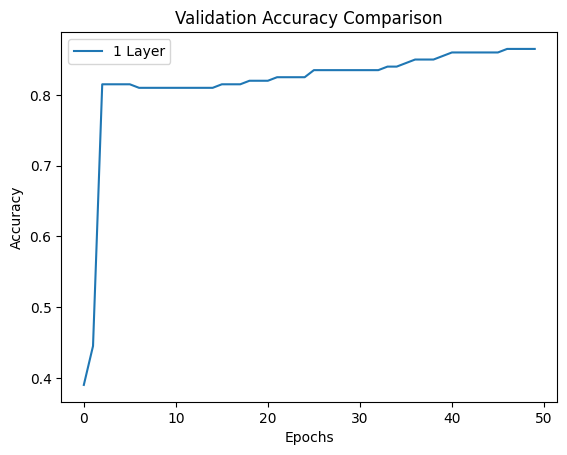

In [ ]:
plt.plot(history_1.history['val_accuracy'], label='1 Layer')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

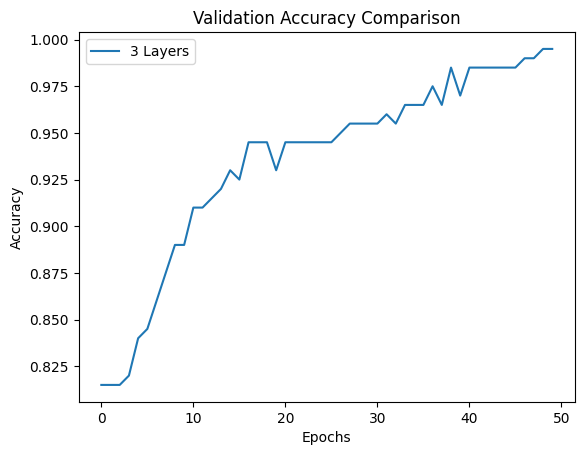

In [ ]:
history_3 = model_3.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=0)
plt.plot(history_3.history['val_accuracy'], label='3 Layers')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


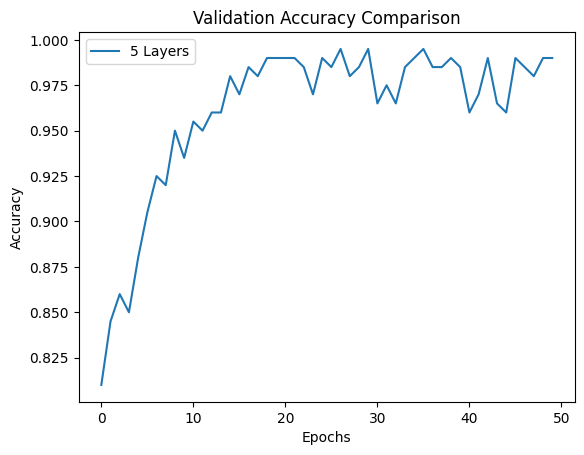

In [ ]:
history_5 = model_5.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=0)
plt.plot(history_5.history['val_accuracy'], label='5 Layers')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


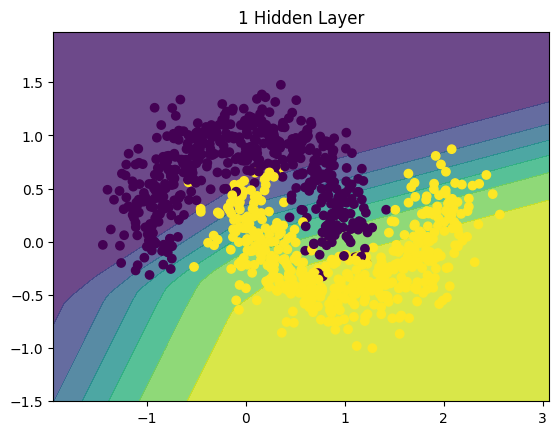

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


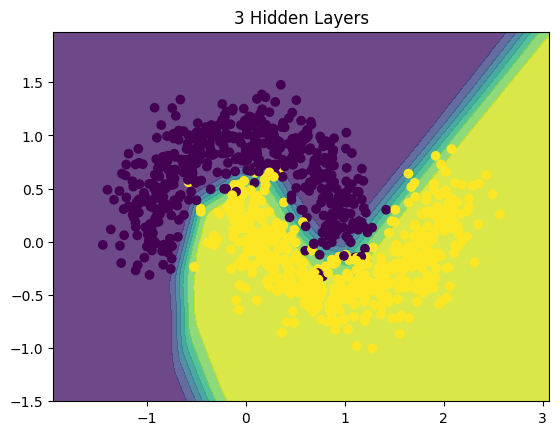

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


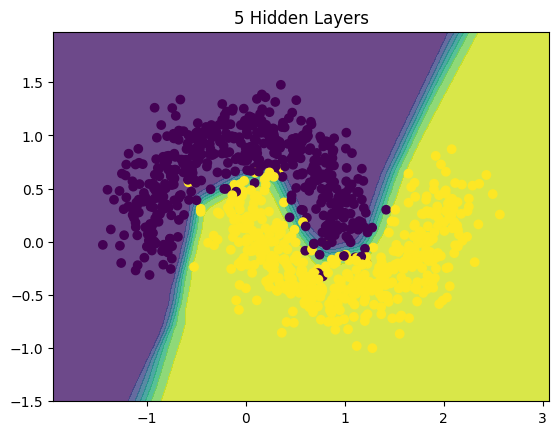

In [ ]:
plot_decision_boundary(model_1, X, y, "1 Hidden Layer")
plot_decision_boundary(model_3, X, y, "3 Hidden Layers")
plot_decision_boundary(model_5, X, y, "5 Hidden Layers")